<a href="https://colab.research.google.com/github/priya-0405/hierarchical/blob/main/hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.read_csv("/content/environmental_socioeconomic.csv")
data.head()

,co2_emissions,waste_production,gdp,population
0,218.543053,436.276737,39199.932440,6.417631e+07
1,477.821438,399.620887,17380.479824,4.646995e+07
2,379.397274,258.538521,23865.587775,9.648535e+07
3,319.396318,646.540003,36531.225474,2.267887e+07
4,120.208388,528.961744,29283.573781,5.919779e+07


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled=scaler.fit_transform(data)
print(pd.DataFrame(data_scaled,columns=data.columns).head())

   co2_emissions  waste_production       gdp  population
0      -0.415900         -0.452465  0.801884    0.482494
1       1.587377         -0.593258 -1.100359   -0.136414
2       0.826917         -1.135149 -0.534981    1.611824
3       0.363328          0.355146  0.569224   -0.968007
4      -1.175669         -0.096466 -0.062635    0.308475


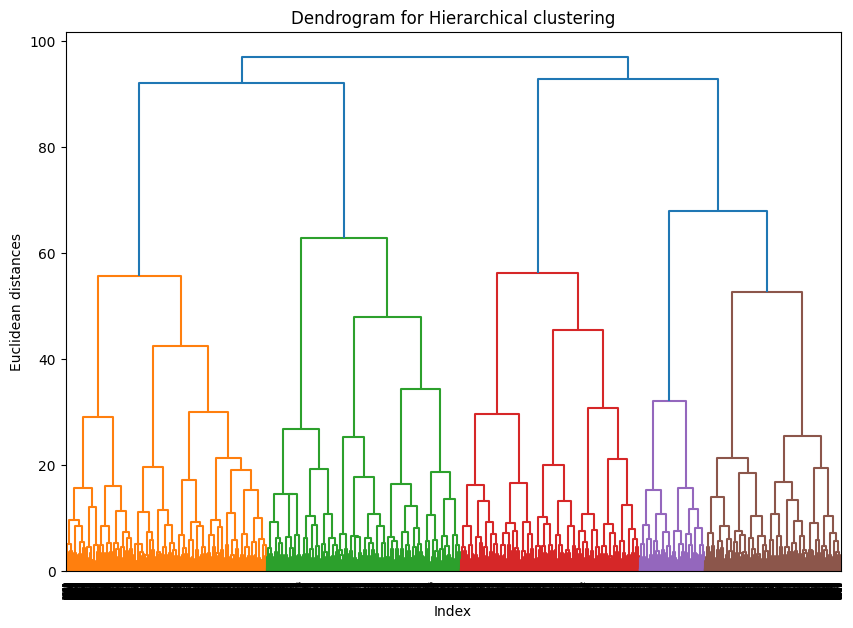

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
plt.figure(figsize=(10,7))
dendrogram = sch.dendrogram(sch.linkage(data_scaled, method = 'ward'))
plt.title('Dendrogram for Hierarchical clustering')
plt.xlabel('Index')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
hierarchical_clustering=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
data['cluster']=hierarchical_clustering.fit_predict(data_scaled)
print(data.head())

   co2_emissions  waste_production           gdp    population  cluster
0     218.543053        436.276737  39199.932440  6.417631e+07        1
1     477.821438        399.620887  17380.479824  4.646995e+07        2
2     379.397274        258.538521  23865.587775  9.648535e+07        2
3     319.396318        646.540003  36531.225474  2.267887e+07        0
4     120.208388        528.961744  29283.573781  5.919779e+07        0


In [ ]:
from sklearn.metrics import silhouette_score
sil_score=silhouette_score(data_scaled,data['cluster'])
print(f'Silhouette Score:{sil_score}')

Silhouette Score:0.1248063320884076


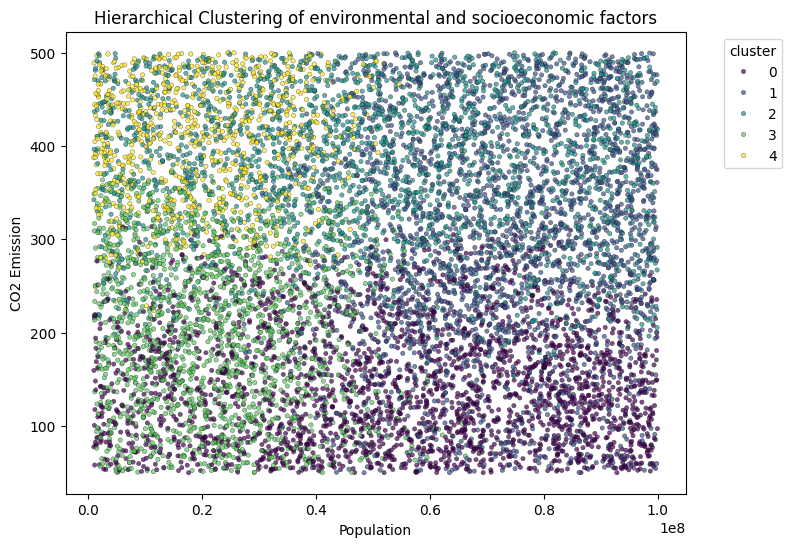

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.scatterplot(x='population',y='co2_emissions',hue='cluster',data=data,palette='viridis',s=10,alpha=0.7,edgecolor='k')
plt.title('Hierarchical Clustering of environmental and socioeconomic factors')
plt.xlabel('Population')
plt.ylabel('CO2 Emission')
plt.legend(title="cluster",bbox_to_anchor=(1.05,1),loc='upper left')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/green transportation system.csv')
df.head()

,energy_efficiency,co2_emissions,electric_vehicle_penetration,cost_efficiency,public_transport_usage
0,17.490802,106.046123,46.499916,2.095361,27.934722
1,29.014286,99.936814,19.225600,1.648231,15.689067
2,24.639879,76.423087,27.331985,2.911246,17.581553
3,21.973170,141.090001,43.164032,1.047446,20.840268
4,13.120373,121.493624,34.104467,1.969641,22.219200


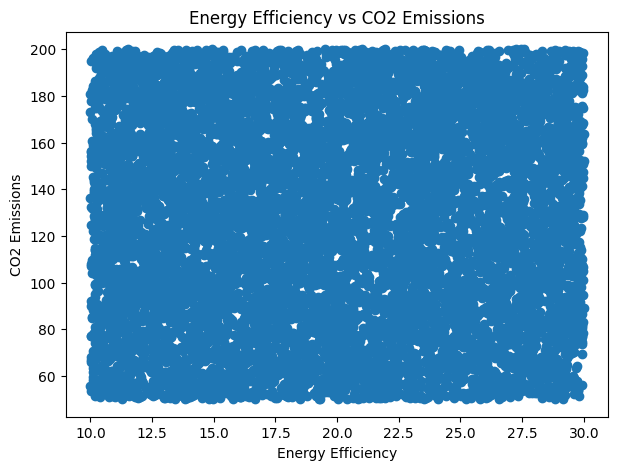

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(df['energy_efficiency'],df['co2_emissions'])
plt.xlabel('Energy Efficiency')
plt.ylabel('CO2 Emissions')
plt.title('Energy Efficiency vs CO2 Emissions')
plt.show()

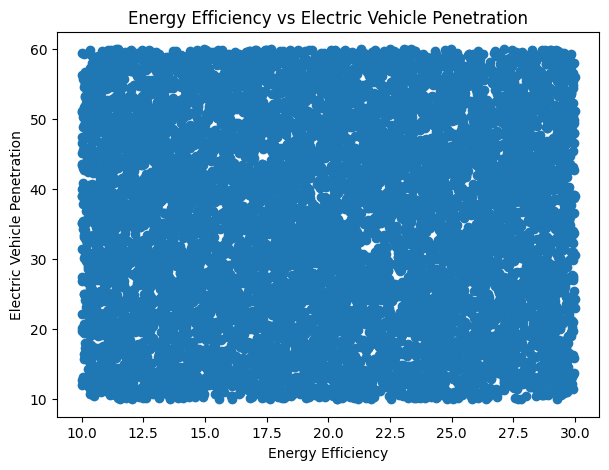

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['energy_efficiency'],df['electric_vehicle_penetration'])
plt.xlabel('Energy Efficiency')
plt.ylabel('Electric Vehicle Penetration')
plt.title('Energy Efficiency vs Electric Vehicle Penetration')
plt.show()

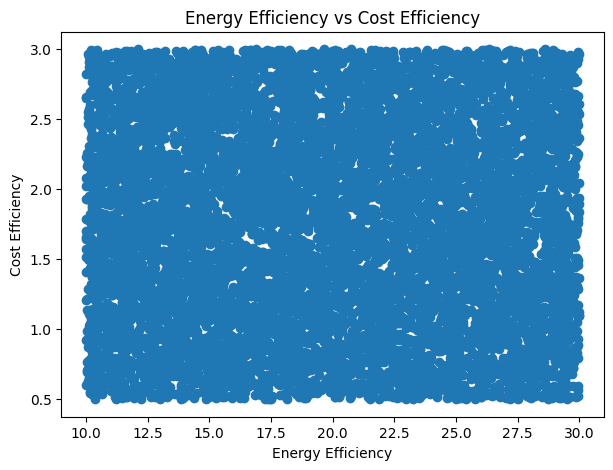

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['energy_efficiency'],df['cost_efficiency'])
plt.xlabel('Energy Efficiency')
plt.ylabel('Cost Efficiency')
plt.title('Energy Efficiency vs Cost Efficiency')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
data = df # Assigning df to data as requested
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
scaled_data = pd.DataFrame(data_scaled, columns=data.columns)
print(scaled_data.head())

   energy_efficiency  co2_emissions  electric_vehicle_penetration  \
0          -0.415900      -0.452465                      0.801884   
1           1.587377      -0.593258                     -1.100359   
2           0.826917      -1.135149                     -0.534981   
3           0.363328       0.355146                      0.569224   
4          -1.175669      -0.096466                     -0.062635   

   cost_efficiency  public_transport_usage  
0         0.482494               -0.684316  
1        -0.136414               -1.389866  
2         1.611824               -1.280827  
3        -0.968007               -1.093072  
4         0.308475               -1.013623  


In [ ]:
from sklearn.decomposition import PCA
pca=PCA()
pca.fit(data_scaled)
print("Explained variance ratio for each principal component")
print(pca.explained_variance_ratio_)
print("\nCumulative explained variance ratio")
print(np.cumsum(pca.explained_variance_ratio_))

Explained variance ratio for each principal component
[0.20669281 0.20317681 0.2012694  0.19634014 0.19252083]

Cumulative explained variance ratio
[0.20669281 0.40986962 0.61113902 0.80747917 1.        ]


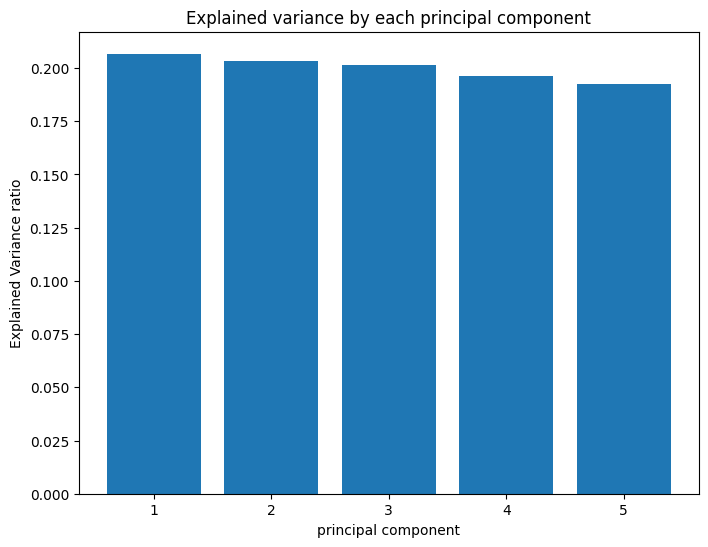

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.bar(range(1,len(pca.explained_variance_ratio_)+1),pca.explained_variance_ratio_)
plt.title('Explained variance by each principal component')
plt.xlabel('principal component')
plt.ylabel('Explained Variance ratio')
plt.show()

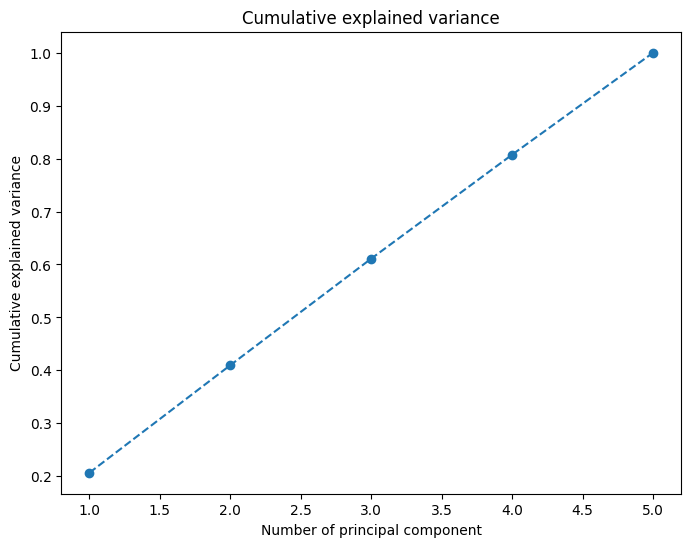

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(range(1,len(pca.explained_variance_ratio_)+1),np.cumsum(pca.explained_variance_ratio_),marker='o',linestyle='--')
plt.title('Cumulative explained variance')
plt.xlabel('Number of principal component')
plt.ylabel('Cumulative explained variance')
plt.show()

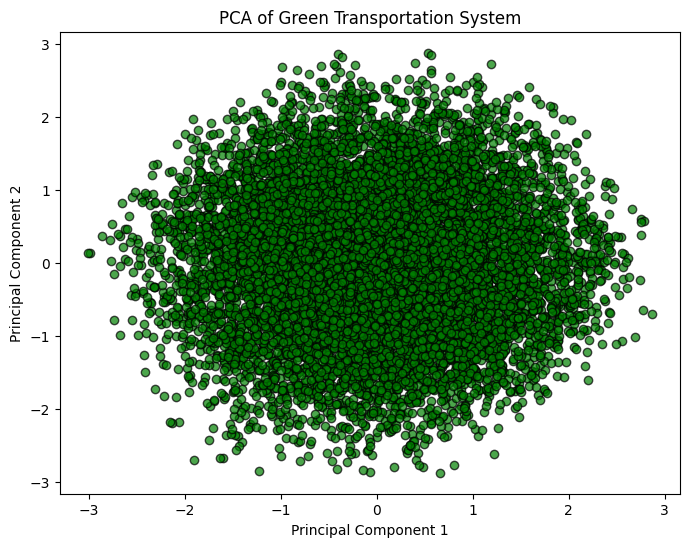

In [ ]:
data_pca=pca.transform(data_scaled)
pca_df=pd.DataFrame(data_pca[:, :2],columns=['PC1','PC2'])
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'],pca_df['PC2'],c='green',edgecolor='k',alpha=0.7)
plt.title('PCA of Green Transportation System')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()